# Test Two-Qubit Gate Sweep Plot

Plot corrected fidelity and latency for the `test_graph_two_qubit_gate_sweep` experiment.


In [36]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


In [37]:
line_re = re.compile(
    r"run_id=(?P<run_id>\d+), time to serve=(?P<latency>[-+0-9.eE]+), "
    r"(?:fidelity_raw=(?P<fidelity_raw>[-+0-9.eE]+), fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+), )?"
    r"fidelity=(?P<fidelity>[-+0-9.eE]+)"
)

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"(?:physbell=(?P<physbell>[0-9.]+|cfg),)?"
    r"ts=(?P<ts>\d{8}_\d{4})"
)


In [38]:
def load_runner_logs(log_dir: Path) -> pd.DataFrame:
    """Load one runner log directory into a flat dataframe.

    Args:
        log_dir: Directory containing runner log files.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows = []
    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue
        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        log_mtime = path.stat().st_mtime
        nodes = int(meta["nodes"])
        num_links = nodes - 1
        elementary_link_km = float(meta["dist"])
        total_distance_km = num_links * elementary_link_km
        t2_value = float(meta["t2"])

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = line_re.search(line)
                if line_match is None:
                    continue
                rows.append({
                    "log_name": path.name,
                    "log_mtime": log_mtime,
                    "nodes": nodes,
                    "num_links": num_links,
                    "elementary_link_km": elementary_link_km,
                    "total_distance_km": total_distance_km,
                    "css_code": meta["code"],
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "gate_fidelity": float(meta["gate"]),
                    "state_preparation_fidelity": float(meta["prep"]),
                    "physical_bell_pair_fidelity": None if meta.get("physbell") in (None, "cfg") else float(meta["physbell"]),
                    "data_t2": t2_value,
                    "comm_t2": t2_value,
                    "t1": float(meta["t1"]),
                    "correction_mode": meta["ccorr"],
                    "ft_prep_mode": meta["ft"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ms": float(line_match["latency"]),
                    "fidelity": float(line_match["fidelity"]),
                    "fidelity_raw": float(line_match["fidelity_raw"]) if line_match["fidelity_raw"] is not None else float(line_match["fidelity"]),
                    "fidelity_corrected": float(line_match["fidelity_corrected"]) if line_match["fidelity_corrected"] is not None else float(line_match["fidelity"]),
                })
    return pd.DataFrame(rows)


Using log_dir: /Users/patange/Documents/Argonne/QEC/log/runner-ideal/test_graph_two_qubit_gate_sweep
Exists: True
row_count: 350
   nodes  two_qubit_gate_fidelity correction_mode  fidelity_corrected  \
0      6                    0.995             cec                 1.0   
1      6                    0.995             cec                 1.0   
2      6                    0.995             cec                 1.0   
3      6                    0.995             cec                 1.0   
4      6                    0.995             cec                 1.0   

   latency_ms  
0    4.743495  
1    4.248588  
2    2.958335  
3    3.423400  
4    3.203435  
nodes: [np.int64(6)]
modes: ['cec']
twoq: [np.float64(0.995), np.float64(0.996), np.float64(0.997), np.float64(0.998), np.float64(0.999), np.float64(0.9995), np.float64(1.0)]


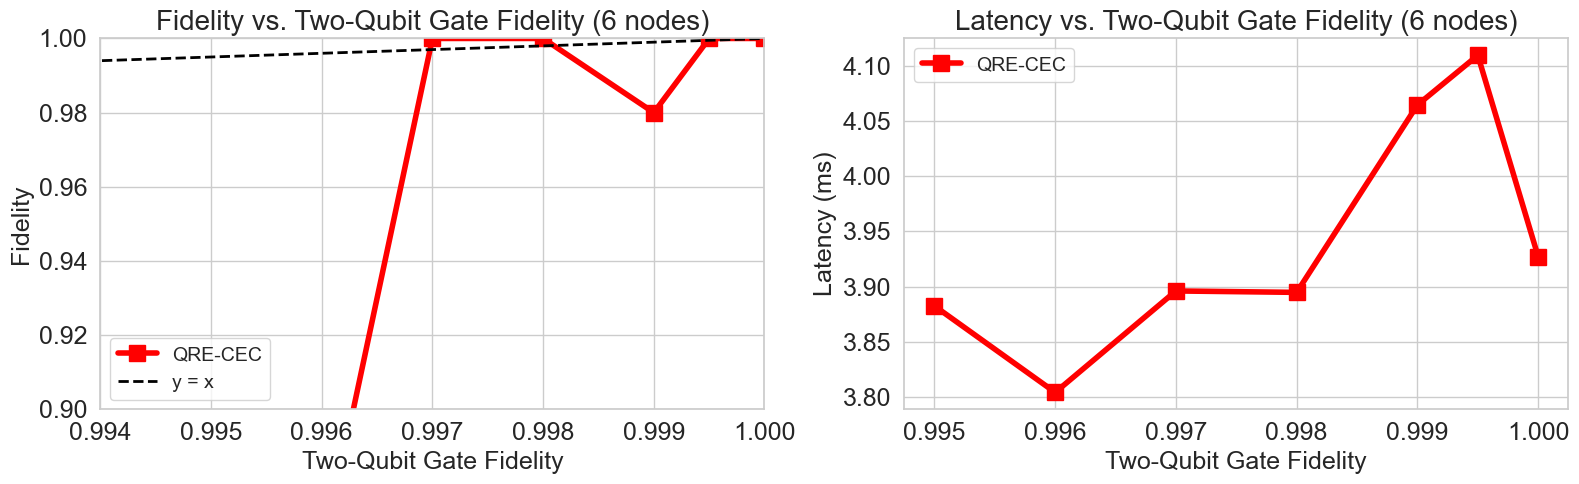

In [40]:
project_dir = Path.cwd()
if not (project_dir / "log").exists() and (project_dir / "QEC" / "log").exists():
    project_dir = project_dir / "QEC"

log_dir = project_dir / "log" / "runner-ideal" / "test_graph_two_qubit_gate_sweep"
output_dir = project_dir / "plot_pngs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Using log_dir:", log_dir)
print("Exists:", log_dir.exists())

test_df = load_runner_logs(log_dir)

print("row_count:", len(test_df))
if not test_df.empty:
    print(test_df[["nodes", "two_qubit_gate_fidelity", "correction_mode", "fidelity_corrected", "latency_ms"]].head())
    print("nodes:", sorted(test_df["nodes"].unique()))
    print("modes:", sorted(test_df["correction_mode"].unique()))
    print("twoq:", sorted(test_df["two_qubit_gate_fidelity"].unique()))

if test_df.empty:
    print("No test_graph_two_qubit_gate_sweep data found.")
else:
    summary = (
        test_df.groupby(["nodes", "two_qubit_gate_fidelity", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
            mean_latency_ms=("latency_ms", "mean"),
        )
        .sort_values(["nodes", "two_qubit_gate_fidelity", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue", "qec": "green"}
    names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
    markers = {"cec": "s", "none": "^", "qec": "o"}

    node_values = sorted(summary["nodes"].unique())
    fig, axes = plt.subplots(len(node_values), 2, figsize=(16, 5 * len(node_values)), squeeze=False)

    for row_index, node_count in enumerate(node_values):
        node_data = summary[summary["nodes"] == node_count]
        ax0 = axes[row_index][0]
        ax1 = axes[row_index][1]

        for protocol in sorted(node_data["correction_mode"].unique()):
            data = node_data[node_data["correction_mode"] == protocol]
            ax0.plot(
                data["two_qubit_gate_fidelity"],
                data["mean_fidelity_corrected"],
                color=colors.get(protocol, "black"),
                marker=markers.get(protocol, "o"),
                linewidth=4,
                markersize=12,
                linestyle="-",
                label=names.get(protocol, protocol),
            )
            ax1.plot(
                data["two_qubit_gate_fidelity"],
                data["mean_latency_ms"],
                color=colors.get(protocol, "black"),
                marker=markers.get(protocol, "o"),
                linewidth=4,
                markersize=12,
                label=names.get(protocol, protocol),
            )

        lower = min(node_data["two_qubit_gate_fidelity"].min(), node_data["mean_fidelity_corrected"].min())
        upper = max(node_data["two_qubit_gate_fidelity"].max(), node_data["mean_fidelity_corrected"].max())
        ax0.plot([lower, upper], [lower, upper], color="black", linestyle="--", linewidth=2, label="y = x")

        ax0.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
        ax0.set_ylabel("Fidelity", fontsize=18)
        ax0.set_title(f"Fidelity vs. Two-Qubit Gate Fidelity ({node_count} nodes)", fontsize=20)
        ax0.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
        ax0.set_ylim(0.9, 1)
        ax0.set_xlim(0.994, 1)
        ax0.tick_params(axis="both", labelsize=18)
        ax0.legend(fontsize=14)

        ax1.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
        ax1.set_ylabel("Latency (ms)", fontsize=18)
        ax1.set_title(f"Latency vs. Two-Qubit Gate Fidelity ({node_count} nodes)", fontsize=20)
        ax1.tick_params(axis="both", labelsize=18)
        ax1.legend(fontsize=14)

    plt.tight_layout()
    plt.savefig(output_dir / "test_graph_two_qubit_gate_sweep.png", dpi=300, bbox_inches="tight")
    plt.show()

    summary
